# Mobil Uygulama Kullanımı — Öznitelik Mühendisliği (Feature Engineering)

Bu defter, `01_eda.ipynb` içindeki keşifçi veri analizinin devamıdır. Amaç, ham veriyi
**değiştirmeden**, modelleme için aday yeni öznitelikler türetmek; her birinin dağılımını,
diğer değişkenlerle korelasyonunu ve hedef değişkenle ilişkisini incelemek; zayıf/gereksiz
olanları elemek ve son öznitelik setini `data/processed/` klasörüne kaydetmektir.

**Bu defterde model eğitimi yapılmıyor** — bu, sıradaki `03_modeling.ipynb` defterinin işi.

## Hedef Değişken Seçimi

`01_eda.ipynb` bölüm 17 (Sonuç ve Sonraki Adımlar), iki olası hedef değişkeni karşılaştırdı:

- `mental_health_impact` (ve ilişkili `screen_time_concern`, `sleep_disruption_from_phone`,
  `wellbeing_risk_score`) — EDA'da ölçülen kullanım davranışıyla **pratik açıdan anlamlı bir
  ilişki bulunamadı** (Cramér's V < 0.1, risk skoru grupları arasında ruh sağlığı bildirimi
  farkı ölçüm hatası düzeyinde). Bu hedefi şimdi modellemek zayıf sinyal beklemek anlamına gelir.
- `app_deleted_and_reinstalled` — EDA'nın açıkça önerdiği **davranışsal** hedef değişken.
  Sınıf dağılımı (~%32 Evet / %68 Hayır) makul derecede dengeli, bu da sınıflandırma için
  uygun bir aday olduğunu gösteriyor.

Bu nedenle bu defterde **`app_deleted_and_reinstalled`** hedef değişken olarak seçildi ve
tüm yeni öznitelikler bu hedefle olan ilişkileri üzerinden değerlendirildi.

## İçindekiler

1. Ortam Kurulumu
2. Veri Yükleme (ham veri, salt okunur)
3. Tip Optimizasyonu & Ön Hazırlık
4. Hedef Değişken
5. Yeni Öznitelik Fikirleri
6. Yeni Özniteliklerin Dağılımı
7. Korelasyon İncelemesi (çoklu doğrusallık dahil)
8. Hedef Değişkenle İlişki Değerlendirmesi
9. Öznitelik Seçimi — Elemeler
10. Son Veri Setinin Oluşturulması ve Kaydedilmesi
11. Özet

## 1. Ortam Kurulumu

Aynı görselleştirme stili ve renk paleti `01_eda.ipynb` ile tutarlılık için burada yeniden tanımlanıyor.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#184f95", "#f0efec", "#b23232"])

GRID_COLOR = "#e1e0d9"
TEXT_MUTED = "#898781"
TEXT_PRIMARY = "#0b0b0b"
SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid")
sns.set_palette(CATEGORICAL)
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "font.size": 10.5,
    "figure.dpi": 110,
    "legend.frameon": False,
})

RANDOM_STATE = 42


def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    return ax


def annotate_h(ax, fmt="{:,.0f}", pad=3, color=TEXT_MUTED, fontsize=9):
    for p in ax.patches:
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(fmt.format(x), (x, y), ha="left", va="center",
                    fontsize=fontsize, color=color, xytext=(pad, 0), textcoords="offset points")


def pct(bool_series):
    return 100 * bool_series.mean()


print("Kütüphaneler yüklendi ve görselleştirme stili yapılandırıldı.")

Kütüphaneler yüklendi ve görselleştirme stili yapılandırıldı.


## 2. Veri Yükleme

Ham veri `data/raw/` klasöründen **salt okunur** biçimde yükleniyor. Bu defter boyunca
`df` üzerinde yalnızca yeni sütunlar eklenecek; mevcut hiçbir sütunun değeri değiştirilmeyecek
ve ham CSV dosyasına hiçbir şekilde yazılmayacak.

In [2]:
import hashlib

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "mobile_app_usage_screen_time.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_FILE_HASH_AT_LOAD = hashlib.sha256(RAW_DATA_PATH.read_bytes()).hexdigest()

df = pd.read_csv(RAW_DATA_PATH)

print(f"Kaynak dosya : {RAW_DATA_PATH}")
print(f"Boyut        : {df.shape[0]:,} satır x {df.shape[1]} sütun")
df.head(3)

Kaynak dosya : /Users/omerburaksal/Desktop/projects/data_science/product_level_mobile/data/raw/mobile_app_usage_screen_time.csv
Boyut        : 10,000 satır x 34 sütun


,record_id,year,month,quarter,day_of_week,country,age_group,gender,device_brand,operating_system,network_connection,app_category,app_name,subscription_type,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,data_used_mb_per_day,battery_drain_pct_per_session,notifications_received_per_day,notification_settings,in_app_purchase,monthly_spend_usd,app_rating_given,review_submitted,primary_usage_time,dark_mode_preference,location_permission,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used,app_deleted_and_reinstalled
0,APP0000001,2024,11,Q4,Thursday,Turkey,45-54,Male,Xiaomi,Android,WiFi,Social Media,Snapchat,Paid Yearly,76.400,41.000,9,12,159.200,3.000,26,Selected Only,Yes,65.280,4,No,Lunch (12-2pm),Sometimes,While Using,Moderate,Yes,Positive,Yes,Yes
1,APP0000002,2022,5,Q2,Friday,USA,25-34,Male,Huawei,Android,WiFi,Shopping,Etsy,Freemium,82.200,19.300,6,9,46.700,11.800,25,Selected Only,No,0.000,4,Yes,Evening (6-10pm),Sometimes,Never,NaN,Yes,Negative,Yes,Yes
2,APP0000003,2024,9,Q3,Sunday,USA,25-34,Male,Samsung,Android,4G/LTE,Food Delivery,Deliveroo,Free,15.800,18.000,2,5,128.900,10.300,25,Selected Only,No,0.000,4,Yes,Evening (6-10pm),Sometimes,While Using,NaN,No,Negative,No,Yes


## 3. Tip Optimizasyonu & Ön Hazırlık

`01_eda.ipynb` ile aynı sıralı (ordinal) kategori tanımları ve eksik değer doldurma
stratejisi burada tekrar uygulanıyor, böylece bu defter bağımsız çalıştırılabiliyor.

In [3]:
AGE_ORDER = ["13-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
AGE_MIDPOINT = {"13-17": 15, "18-24": 21, "25-34": 29.5, "35-44": 39.5,
                "45-54": 49.5, "55-64": 59.5, "65+": 70}
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
SLEEP_ORDER = ["Mild", "Moderate", "Severe"]
SLEEP_MAP = {"Mild": 0, "Moderate": 1, "Severe": 2}
CONCERN_ORDER = ["No", "Somewhat", "Yes"]
CONCERN_MAP = {"No": 0, "Somewhat": 1, "Yes": 2}
SUBSCRIPTION_ORDER = ["Free", "Freemium", "Paid Monthly", "Paid Yearly", "One-time Purchase"]
NOTIF_ORDER = ["Completely Off", "Silent/Badge Only", "Selected Only", "All Notifications"]
NOTIF_MAP = {v: i for i, v in enumerate(NOTIF_ORDER)}
DARKMODE_ORDER = ["Never", "Sometimes", "Always"]
DARKMODE_MAP = {v: i for i, v in enumerate(DARKMODE_ORDER)}

# sleep_disruption_from_phone'daki eksik değerler "uygulanamaz/cevap yok" anlamına geliyor
# (bkz. 01_eda.ipynb bölüm 4.2) -- ayrı bir "bildirildi mi?" bayrağıyla ele alınıyor,
# ordinal koda dahil edilmiyor (aksi halde eksikliğe rastgele bir sıra değeri atanmış olurdu).
df["sleep_disruption_reported"] = df["sleep_disruption_from_phone"].notna()

print("Ön hazırlık tamamlandı.")
print(f"sleep_disruption_from_phone bildirilme oranı: %{pct(df['sleep_disruption_reported']):.1f}")

Ön hazırlık tamamlandı.
sleep_disruption_from_phone bildirilme oranı: %72.3


## 4. Hedef Değişken

`app_deleted_and_reinstalled` (Evet/Hayır) ikili hedef değişken olarak kodlanıyor:
`target = 1` → kullanıcı uygulamayı silip yeniden yüklemiş.

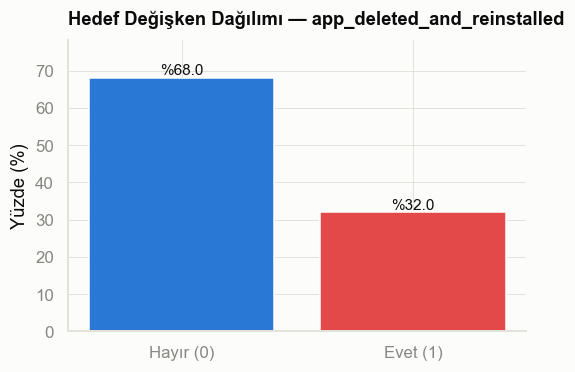

Sınıf dengesi -> Hayır: %68.0 | Evet: %32.0
Yorum: İki sınıf da yeterince temsil ediliyor (ne aşırı dengesiz ne de yapay biçimde 50/50);
bu, ileride kurulacak bir sınıflandırma modeli için makul bir başlangıç noktası.


In [4]:
df["target"] = (df["app_deleted_and_reinstalled"] == "Yes").astype(int)

target_dist = df["target"].value_counts(normalize=True).sort_index() * 100
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Hayır (0)", "Evet (1)"], target_dist.values, color=[CATEGORICAL[0], CATEGORICAL[7]])
for i, v in enumerate(target_dist.values):
    ax.annotate(f"%{v:.1f}", (i, v), ha="center", va="bottom", fontsize=10)
style_ax(ax, title="Hedef Değişken Dağılımı — app_deleted_and_reinstalled", ylabel="Yüzde (%)")
ax.set_ylim(0, max(target_dist.values) * 1.15)
plt.tight_layout()
plt.show()

print(f"Sınıf dengesi -> Hayır: %{target_dist.loc[0]:.1f} | Evet: %{target_dist.loc[1]:.1f}")
print("Yorum: İki sınıf da yeterince temsil ediliyor (ne aşırı dengesiz ne de yapay biçimde 50/50);")
print("bu, ileride kurulacak bir sınıflandırma modeli için makul bir başlangıç noktası.")

## 5. Yeni Öznitelik Fikirleri

Aşağıdaki öznitelikler beş grupta türetiliyor. Her grup, ham sütunların doğrudan
ifade etmediği bir **davranışsal yoğunluk, oran veya bileşik gösterge** yakalamayı hedefliyor.

### 5.1 Kullanım Yoğunluğu Oranları

Ham veri toplam/ortalama değerler sunuyor (`daily_screen_time_minutes`, `sessions_per_day`,
`app_opens_per_day` vb.); bunların birbirine oranı, kullanım *şeklini* (ör. az sayıda uzun
oturum mu, çok sayıda kısa oturum mu) ortaya çıkarabilir.

In [5]:
df["screen_time_hours"] = df["daily_screen_time_minutes"] / 60

# Ham veride zaten bir session_duration_minutes var; bu, ondan bağımsız olarak
# toplam ekran süresi / oturum sayısından türetilen alternatif bir tahmin --
# ikisi arasındaki fark, iki metriğin farklı şeyleri ölçüp ölçmediğini gösterecek (bkz. bölüm 7).
df["computed_minutes_per_session"] = df["daily_screen_time_minutes"] / df["sessions_per_day"]

df["opens_per_session"] = df["app_opens_per_day"] / df["sessions_per_day"]
df["data_mb_per_minute"] = df["data_used_mb_per_day"] / df["daily_screen_time_minutes"]
df["notifications_per_session"] = df["notifications_received_per_day"] / df["sessions_per_day"]

# Oturum başına pil tüketimi x günlük oturum sayısı: kaba bir "günlük toplam pil yükü" göstergesi
# (oturumların bağımsız/eklemeli olduğu varsayımıyla; kesin bir fizik ölçümü değil, karşılaştırmalı bir proxy).
df["daily_battery_load"] = df["battery_drain_pct_per_session"] * df["sessions_per_day"]

ratio_cols = ["computed_minutes_per_session", "opens_per_session", "data_mb_per_minute",
              "notifications_per_session", "daily_battery_load"]
df[ratio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
computed_minutes_per_session,"10,000.000",18.011,22.176,0.592,6.057,11.438,21.735,355.100
opens_per_session,"10,000.000",1.671,1.305,0.100,0.909,1.333,2.000,17.000
data_mb_per_minute,"10,000.000",2.816,4.071,0.092,0.886,1.591,3.052,68.035
notifications_per_session,"10,000.000",5.218,3.720,0.917,3.143,4.200,6.000,38.000
daily_battery_load,"10,000.000",111.682,77.370,2.100,50.000,95.600,158.600,514.500


### 5.2 Parasal (Monetization) Öznitelikler

In [6]:
df["is_payer"] = (df["monthly_spend_usd"] > 0).astype(int)
df["spend_per_minute"] = df["monthly_spend_usd"] / df["daily_screen_time_minutes"]
df["is_paid_subscription"] = df["subscription_type"].isin(
    ["Paid Monthly", "Paid Yearly", "One-time Purchase"]
).astype(int)

print(f"Ödeme yapan kullanıcı oranı (is_payer)          : %{pct(df['is_payer'] == 1):.1f}")
print(f"Ücretli abonelik oranı (is_paid_subscription)   : %{pct(df['is_paid_subscription'] == 1):.1f}")
df[["is_payer", "spend_per_minute", "is_paid_subscription"]].describe().T

Ödeme yapan kullanıcı oranı (is_payer)          : %27.6
Ücretli abonelik oranı (is_paid_subscription)   : %30.2


,count,mean,std,min,25%,50%,75%,max
is_payer,"10,000.000",0.276,0.447,0.000,0.000,0.000,1.000,1.000
spend_per_minute,"10,000.000",0.172,0.566,0.000,0.000,0.000,0.075,15.301
is_paid_subscription,"10,000.000",0.302,0.459,0.000,0.000,0.000,1.000,1.000


### 5.3 Ordinal Kodlamalar

Gerçekten sıralı (ordinal) olan kategorik sütunlar, sıralarını koruyacak biçimde
sayısala çevriliyor -- bu, korelasyon/mutual-information analizlerinde kullanılabilmelerini sağlıyor.

In [7]:
df["age_group_numeric"] = df["age_group"].map(AGE_MIDPOINT)
df["notification_settings_numeric"] = df["notification_settings"].map(NOTIF_MAP)
df["screen_time_concern_numeric"] = df["screen_time_concern"].map(CONCERN_MAP)
df["dark_mode_numeric"] = df["dark_mode_preference"].map(DARKMODE_MAP)
# Sadece "bildirilmiş" kayıtlarda anlamlı; bildirilmemiş olanlar NaN kalıyor
# (bkz. sleep_disruption_reported bayrağı -- eksikliğin kendisi ayrı bir sinyal).
df["sleep_disruption_numeric"] = df["sleep_disruption_from_phone"].map(SLEEP_MAP)

ordinal_cols = ["age_group_numeric", "notification_settings_numeric", "screen_time_concern_numeric",
                "dark_mode_numeric", "sleep_disruption_numeric"]
df[ordinal_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age_group_numeric,"10,000.000",32.473,13.181,15.000,21.000,29.500,39.500,70.000
notification_settings_numeric,"10,000.000",1.993,0.945,0.000,1.000,2.000,3.000,3.000
screen_time_concern_numeric,"10,000.000",1.023,0.853,0.000,0.000,1.000,2.000,2.000
dark_mode_numeric,"10,000.000",1.127,0.837,0.000,0.000,1.000,2.000,2.000
sleep_disruption_numeric,"7,233.000",0.709,0.758,0.000,0.000,1.000,1.000,2.000


### 5.4 Zamansal Öznitelikler

In [8]:
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print(f"Hafta sonu kayıt oranı: %{pct(df['is_weekend'] == 1):.1f} (beklenen ~%28.6, 7 günden 2'si)")
df[["is_weekend", "month_sin", "month_cos"]].describe().T

Hafta sonu kayıt oranı: %31.4 (beklenen ~%28.6, 7 günden 2'si)


,count,mean,std,min,25%,50%,75%,max
is_weekend,"10,000.000",0.314,0.464,0.000,0.000,0.000,1.000,1.000
month_sin,"10,000.000",-0.005,0.708,-1.000,-0.866,-0.000,0.866,1.000
month_cos,"10,000.000",-0.004,0.706,-1.000,-0.500,-0.000,0.500,1.000


### 5.5 Kategorik Sıklık / Bayrak Öznitelikleri

In [9]:
df["is_ios"] = (df["operating_system"] == "iOS").astype(int)

# Uygulama kategorisinin genel popülerliği (kaç kayıtta göründüğü) -- bir "yaygınlık" proxysi.
category_freq = df["app_category"].value_counts(normalize=True)
df["app_category_frequency"] = df["app_category"].map(category_freq)

df["location_always_or_using"] = df["location_permission"].isin(["Always", "While Using"]).astype(int)

print("Not: 'app_category_reinstall_rate' gibi hedefe göre ortalama kodlama (target/mean encoding)")
print("bilinçli olarak EKLENMEDİ -- eğitim/test ayrımı yapılmadan hesaplanan böyle bir kodlama,")
print("hedef bilgisini öznitelik olarak sızdırır (data leakage). Bu tür kodlamalar ancak")
print("03_modeling.ipynb içinde çapraz doğrulama (cross-validation) katları içinde güvenle üretilebilir.")

df[["is_ios", "app_category_frequency", "location_always_or_using"]].describe().T

Not: 'app_category_reinstall_rate' gibi hedefe göre ortalama kodlama (target/mean encoding)
bilinçli olarak EKLENMEDİ -- eğitim/test ayrımı yapılmadan hesaplanan böyle bir kodlama,
hedef bilgisini öznitelik olarak sızdırır (data leakage). Bu tür kodlamalar ancak
03_modeling.ipynb içinde çapraz doğrulama (cross-validation) katları içinde güvenle üretilebilir.


,count,mean,std,min,25%,50%,75%,max
is_ios,"10,000.000",0.285,0.451,0.000,0.000,0.000,1.000,1.000
app_category_frequency,"10,000.000",0.113,0.052,0.009,0.072,0.096,0.137,0.199
location_always_or_using,"10,000.000",0.597,0.491,0.000,0.000,1.000,1.000,1.000


### 5.6 Bileşik Dijital Refah Göstergeleri

`01_eda.ipynb` bölüm 5 ve 14.7'de tanımlanan bileşik göstergeler, bu defterde de
aday öznitelik olarak yeniden üretiliyor ve hedefle ilişkileri test edilecek.

In [10]:
df["screen_time_bucket"] = pd.qcut(
    df["daily_screen_time_minutes"], q=4, labels=["Düşük", "Orta", "Yüksek", "Çok Yüksek"]
)
df["high_screen_time_flag"] = df["screen_time_bucket"].isin(["Yüksek", "Çok Yüksek"]).astype(int)
df["sleep_disruption_flag"] = df["sleep_disruption_from_phone"].isin(["Moderate", "Severe"]).astype(int)
df["concern_flag"] = df["screen_time_concern"].isin(["Somewhat", "Yes"]).astype(int)
df["wellbeing_risk_score"] = (
    df["high_screen_time_flag"] + df["sleep_disruption_flag"] + df["concern_flag"]
)

new_numeric_features = [
    "screen_time_hours", "computed_minutes_per_session", "opens_per_session", "data_mb_per_minute",
    "notifications_per_session", "daily_battery_load", "is_payer", "spend_per_minute",
    "is_paid_subscription", "age_group_numeric", "notification_settings_numeric",
    "screen_time_concern_numeric", "dark_mode_numeric", "sleep_disruption_numeric",
    "is_weekend", "month_sin", "month_cos", "is_ios", "app_category_frequency",
    "location_always_or_using", "high_screen_time_flag", "sleep_disruption_flag",
    "concern_flag", "wellbeing_risk_score",
]
print(f"Toplam aday yeni öznitelik sayısı: {len(new_numeric_features)}")
print(new_numeric_features)

Toplam aday yeni öznitelik sayısı: 24
['screen_time_hours', 'computed_minutes_per_session', 'opens_per_session', 'data_mb_per_minute', 'notifications_per_session', 'daily_battery_load', 'is_payer', 'spend_per_minute', 'is_paid_subscription', 'age_group_numeric', 'notification_settings_numeric', 'screen_time_concern_numeric', 'dark_mode_numeric', 'sleep_disruption_numeric', 'is_weekend', 'month_sin', 'month_cos', 'is_ios', 'app_category_frequency', 'location_always_or_using', 'high_screen_time_flag', 'sleep_disruption_flag', 'concern_flag', 'wellbeing_risk_score']


## 6. Yeni Özniteliklerin Dağılımı

Türetilen sayısal özniteliklerin dağılımları inceleniyor -- aşırı çarpıklık, sonsuz/aykırı
değer veya neredeyse sabit (near-zero-variance) sütun olup olmadığı kontrol ediliyor.

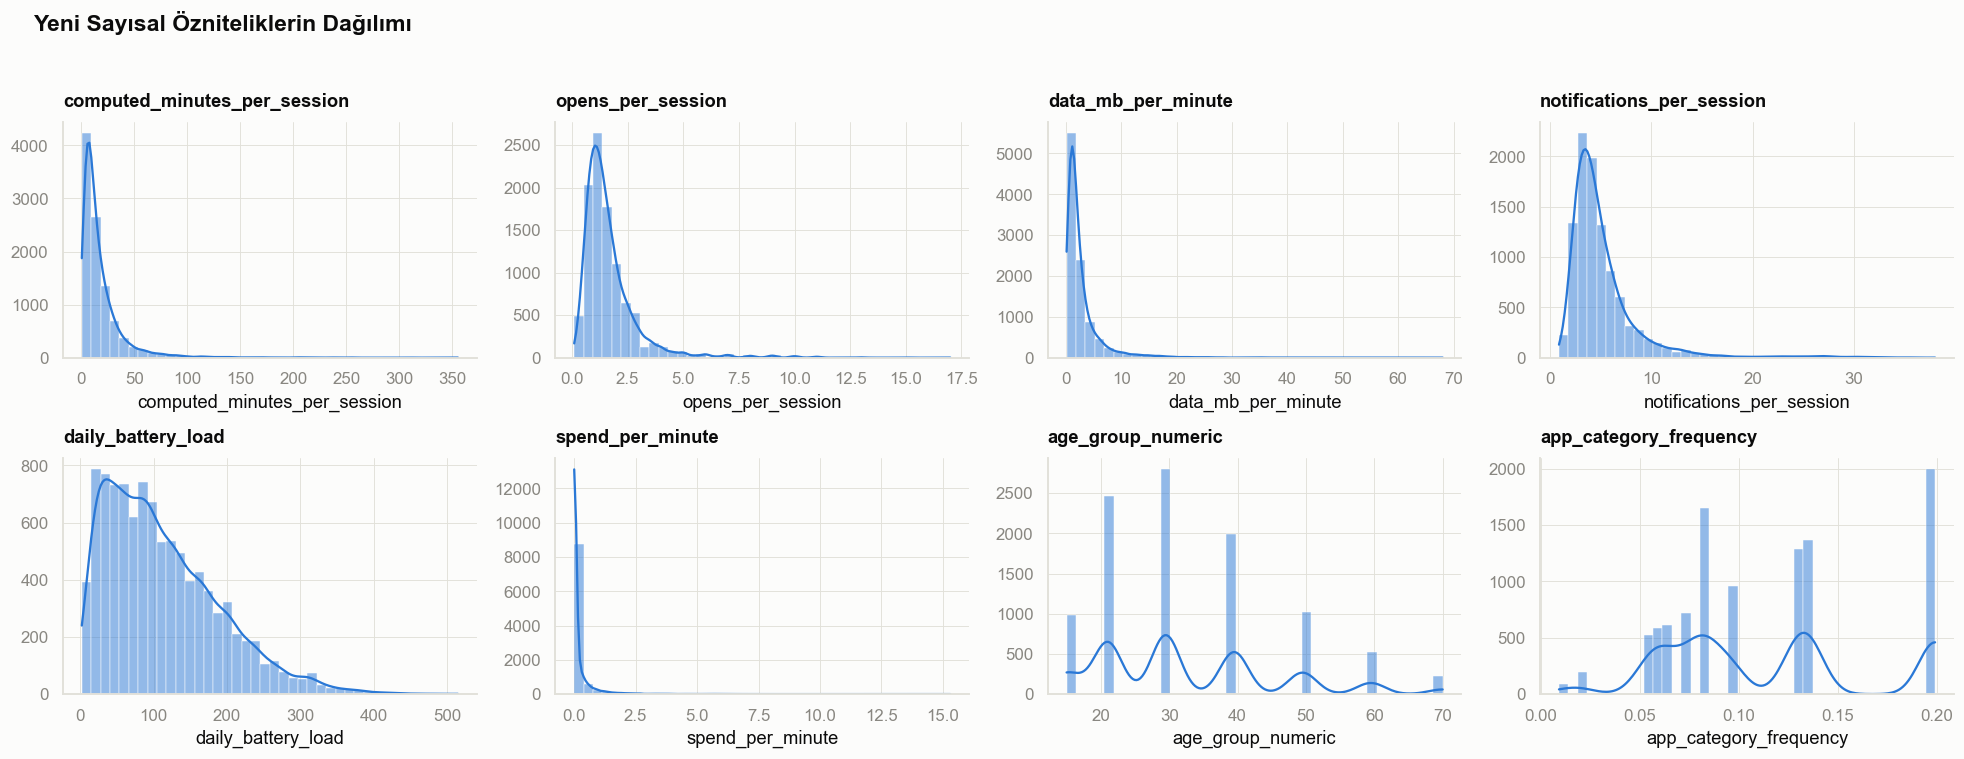

Çarpıklık (skewness) -- |skew| > 2 olan öznitelikler sağ/sol kuyruklu, log/robust ölçekleme
gerektirebilir (bu defterde ölçekleme yapılmıyor, karar 03_modeling.ipynb'e bırakılıyor):

spend_per_minute                 8.470
data_mb_per_minute               5.470
computed_minutes_per_session     4.920
notifications_per_session        3.520
opens_per_session                3.520
screen_time_hours                1.980
is_payer                         1.000
daily_battery_load               0.970
is_ios                           0.950
is_paid_subscription             0.860
age_group_numeric                0.820
is_weekend                       0.800
notification_settings_numeric   -0.630
concern_flag                    -0.620
sleep_disruption_numeric         0.540
sleep_disruption_flag            0.500
app_category_frequency           0.430
location_always_or_using        -0.390
dark_mode_numeric               -0.240
screen_time_concern_numeric     -0.040
month_sin                        0.02

In [11]:
dist_check_cols = ["computed_minutes_per_session", "opens_per_session", "data_mb_per_minute",
                    "notifications_per_session", "daily_battery_load", "spend_per_minute",
                    "age_group_numeric", "app_category_frequency"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, dist_check_cols):
    sns.histplot(df[col], bins=40, kde=True, color=CATEGORICAL[0], edgecolor="white", linewidth=0.3, ax=ax)
    style_ax(ax, title=col)
    ax.set_ylabel("")
fig.suptitle("Yeni Sayısal Özniteliklerin Dağılımı", fontsize=15, fontweight="bold", x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

skew_table = df[new_numeric_features].skew().sort_values(key=np.abs, ascending=False)
print("Çarpıklık (skewness) -- |skew| > 2 olan öznitelikler sağ/sol kuyruklu, log/robust ölçekleme")
print("gerektirebilir (bu defterde ölçekleme yapılmıyor, karar 03_modeling.ipynb'e bırakılıyor):\n")
print(skew_table.round(2).to_string())

In [12]:
near_constant = []
for col in new_numeric_features:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_share > 0.99:
        near_constant.append((col, round(100 * top_share, 2)))

if near_constant:
    print("Neredeyse sabit (near-zero-variance) öznitelikler (baskın değer payı > %99):")
    for col, share in near_constant:
        print(f"  - {col}: en sık değer payı %{share}")
else:
    print("Neredeyse sabit öznitelik bulunmadı -- tüm adaylar yeterli varyansa sahip.")

inf_check = df[new_numeric_features].replace([np.inf, -np.inf], np.nan).isna().sum() - df[new_numeric_features].isna().sum()
inf_cols = inf_check[inf_check > 0]
print(f"\nSonsuz (inf) değer taşıyan öznitelik sayısı: {len(inf_cols)}")
if len(inf_cols) > 0:
    print(inf_cols)

Neredeyse sabit öznitelik bulunmadı -- tüm adaylar yeterli varyansa sahip.

Sonsuz (inf) değer taşıyan öznitelik sayısı: 0


## 7. Korelasyon İncelemesi (Çoklu Doğrusallık Dahil)

Yeni özniteliklerin hem birbirleriyle hem de orijinal sayısal sütunlarla korelasyonuna bakılıyor.
Amaç iki yönlü: (a) beklenen ilişkilerin gerçekten var olduğunu doğrulamak (ör.
`computed_minutes_per_session` ile ham `session_duration_minutes` ne kadar örtüşüyor?),
(b) **çoklu doğrusallık** taşıyan çiftleri tespit edip birini elemeye aday göstermek.

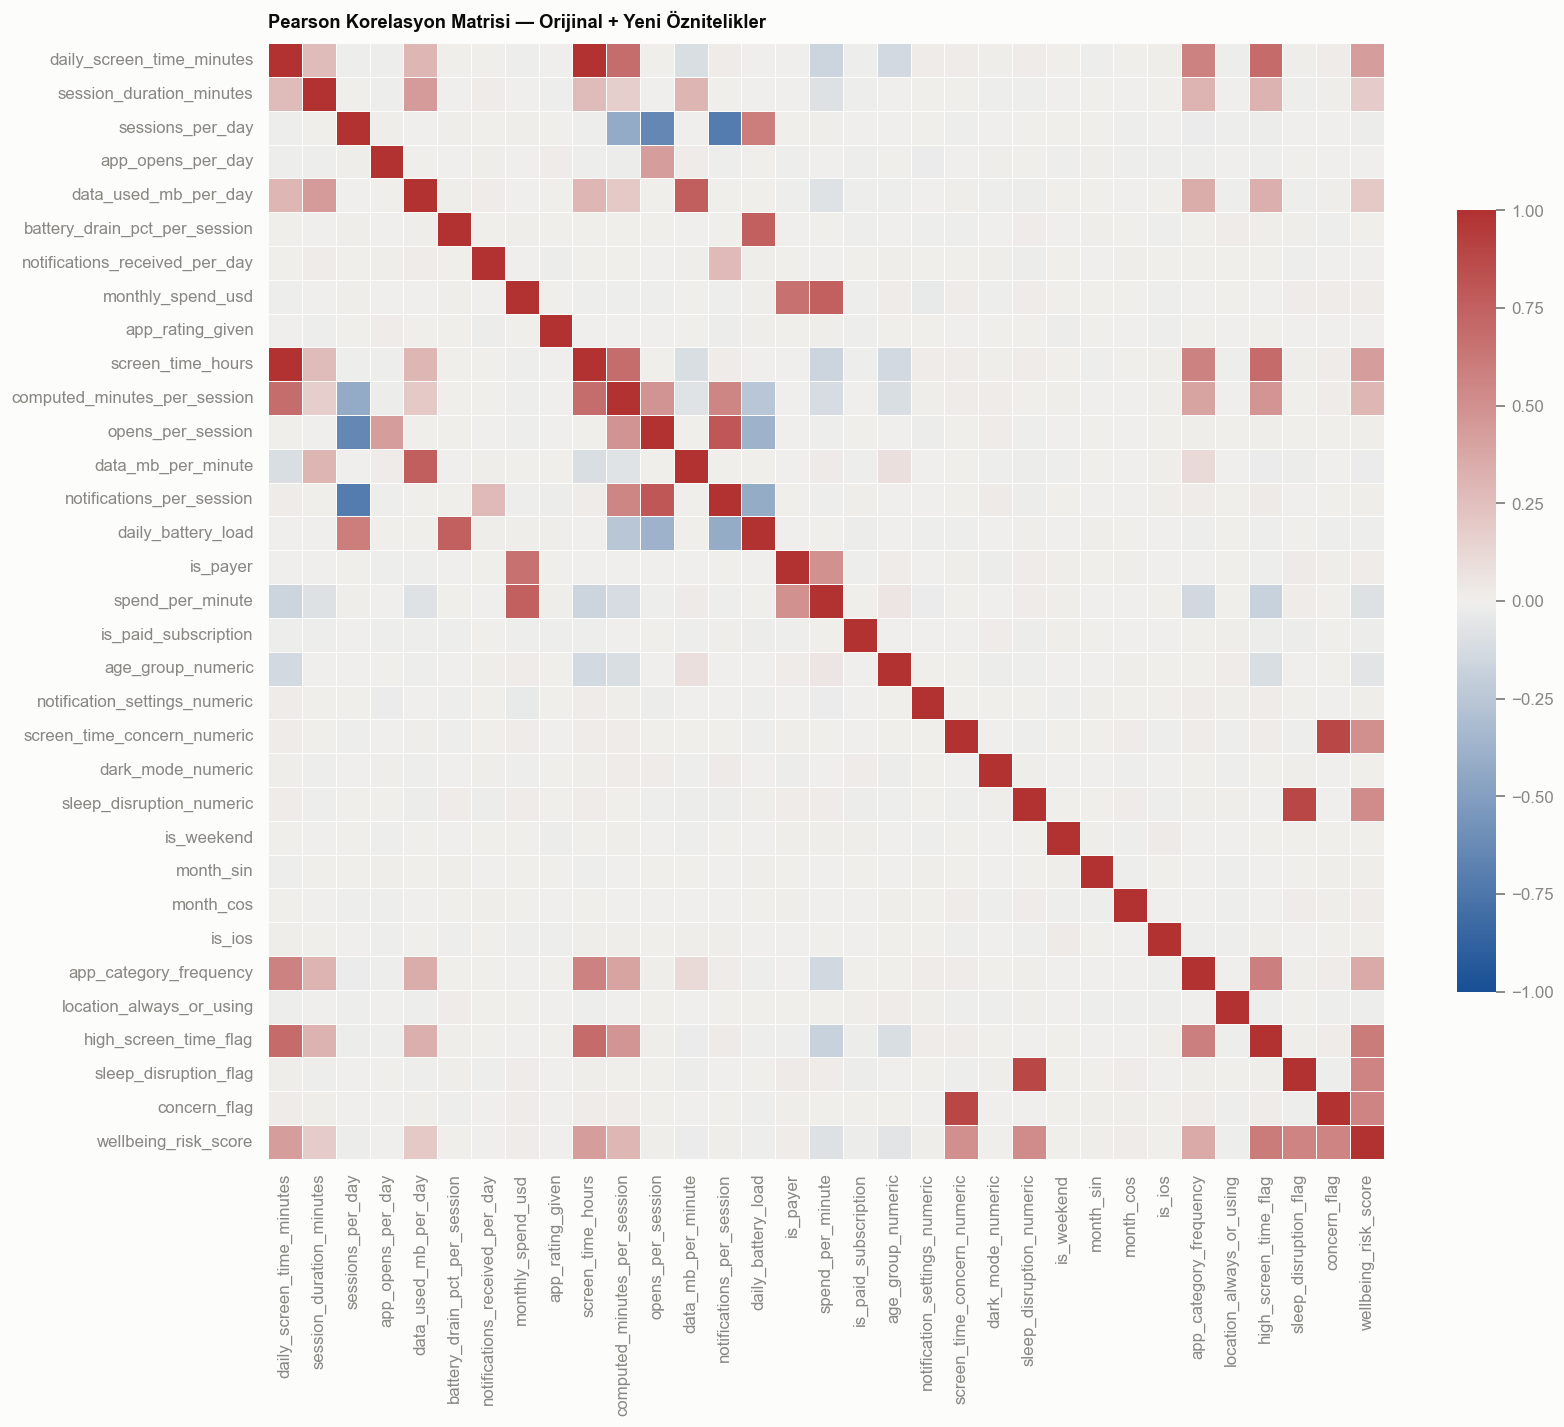

In [13]:
original_numeric = [
    "daily_screen_time_minutes", "session_duration_minutes", "sessions_per_day",
    "app_opens_per_day", "data_used_mb_per_day", "battery_drain_pct_per_session",
    "notifications_received_per_day", "monthly_spend_usd", "app_rating_given",
]
all_numeric_for_corr = original_numeric + new_numeric_features
corr_full = df[all_numeric_for_corr].corr(method="pearson")

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_full, cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor=SURFACE, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
style_ax(ax, title="Pearson Korelasyon Matrisi — Orijinal + Yeni Öznitelikler")
plt.tight_layout()
plt.show()

In [14]:
# Öz-korelasyonu (bir sütunun kendisiyle) hariç tutarak en yüksek mutlak korelasyonlu çiftleri listele
corr_pairs = (
    corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
    .stack()
    .rename("korelasyon")
    .reset_index()
    .rename(columns={"level_0": "degisken_1", "level_1": "degisken_2"})
)
corr_pairs["mutlak_korelasyon"] = corr_pairs["korelasyon"].abs()

HIGH_CORR_THRESHOLD = 0.85
high_corr_pairs = corr_pairs[corr_pairs["mutlak_korelasyon"] >= HIGH_CORR_THRESHOLD].sort_values(
    "mutlak_korelasyon", ascending=False
)
print(f"Eşik (|r| >= {HIGH_CORR_THRESHOLD}) üzerindeki çoklu doğrusallık çiftleri:")
high_corr_pairs.drop(columns="mutlak_korelasyon")

Eşik (|r| >= 0.85) üzerindeki çoklu doğrusallık çiftleri:


,degisken_1,degisken_2,korelasyon
9,daily_screen_time_minutes,screen_time_hours,1.000
756,sleep_disruption_numeric,sleep_disruption_flag,0.890
691,screen_time_concern_numeric,concern_flag,0.885


## 8. Hedef Değişkenle İlişki Değerlendirmesi

Her aday özniteliğin `target` (`app_deleted_and_reinstalled`) ile ilişkisi üç açıdan test ediliyor:

- **Sayısal öznitelikler:** point-biserial korelasyon (yön + büyüklük) ve Mann-Whitney U testi (p-değeri)
- **Kategorik öznitelikler:** Cramér's V (büyüklük) ve ki-kare testi (p-değeri)
- **Birleşik sıralama:** mutual information (doğrusal olmayan ilişkileri de yakalar)

In [15]:
def point_biserial_table(cols, target, frame):
    rows = []
    for col in cols:
        valid = frame[[col]].join(target).dropna()
        if valid[col].nunique() < 2:
            continue
        r, p = stats.pointbiserialr(valid["target"], valid[col])
        u_stat, u_p = stats.mannwhitneyu(
            valid.loc[valid["target"] == 1, col], valid.loc[valid["target"] == 0, col]
        )
        rows.append({"oznitelik": col, "point_biserial_r": r, "mannwhitney_p": u_p,
                     "n_gecerli": len(valid)})
    out = pd.DataFrame(rows)
    out["mutlak_r"] = out["point_biserial_r"].abs()
    return out.sort_values("mutlak_r", ascending=False).drop(columns="mutlak_r").reset_index(drop=True)

numeric_vs_target = point_biserial_table(all_numeric_for_corr, df[["target"]], df)
numeric_vs_target

,oznitelik,point_biserial_r,mannwhitney_p,n_gecerli
0,age_group_numeric,0.037,0.000,10000
1,location_always_or_using,-0.027,0.006,10000
2,month_sin,-0.022,0.023,10000
3,app_opens_per_day,0.018,0.092,10000
4,daily_battery_load,0.016,0.033,10000
5,notifications_per_session,-0.015,0.152,10000
6,battery_drain_pct_per_session,0.014,0.173,10000
7,computed_minutes_per_session,-0.013,0.106,10000
8,high_screen_time_flag,-0.013,0.190,10000
9,data_used_mb_per_day,-0.013,0.742,10000


In [16]:
def cramers_v(col_a, col_b, frame):
    ct = pd.crosstab(frame[col_a], frame[col_b])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    return v, p

categorical_candidates = [
    "country", "age_group", "gender", "device_brand", "operating_system", "network_connection",
    "app_category", "subscription_type", "notification_settings", "primary_usage_time",
    "dark_mode_preference", "location_permission", "sleep_disruption_from_phone",
    "screen_time_concern", "mental_health_impact", "digital_wellbeing_feature_used",
    "in_app_purchase", "review_submitted", "day_of_week", "quarter", "screen_time_bucket",
]

rows = []
for col in categorical_candidates:
    v, p = cramers_v(col, "app_deleted_and_reinstalled", df)
    rows.append({"oznitelik": col, "cramers_v": v, "chi2_p": p})
categorical_vs_target = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
categorical_vs_target

,oznitelik,cramers_v,chi2_p
0,age_group,0.041,0.009
1,app_category,0.041,0.104
2,country,0.036,0.504
3,day_of_week,0.036,0.045
4,device_brand,0.033,0.264
5,primary_usage_time,0.032,0.065
6,location_permission,0.028,0.047
7,mental_health_impact,0.022,0.289
8,quarter,0.022,0.176
9,digital_wellbeing_feature_used,0.021,0.033


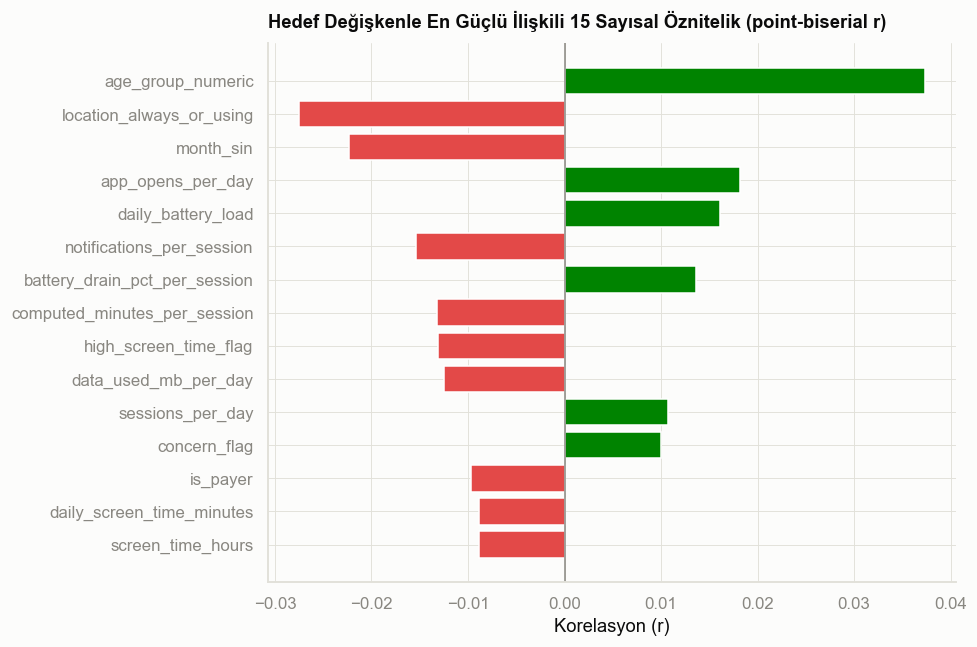

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
top_num = numeric_vs_target.head(15).iloc[::-1]
colors = [CATEGORICAL[1] if r >= 0 else CATEGORICAL[7] for r in top_num["point_biserial_r"]]
ax.barh(top_num["oznitelik"], top_num["point_biserial_r"], color=colors)
ax.axvline(0, color=TEXT_MUTED, linewidth=1)
style_ax(ax, title="Hedef Değişkenle En Güçlü İlişkili 15 Sayısal Öznitelik (point-biserial r)",
         xlabel="Korelasyon (r)")
plt.tight_layout()
plt.show()

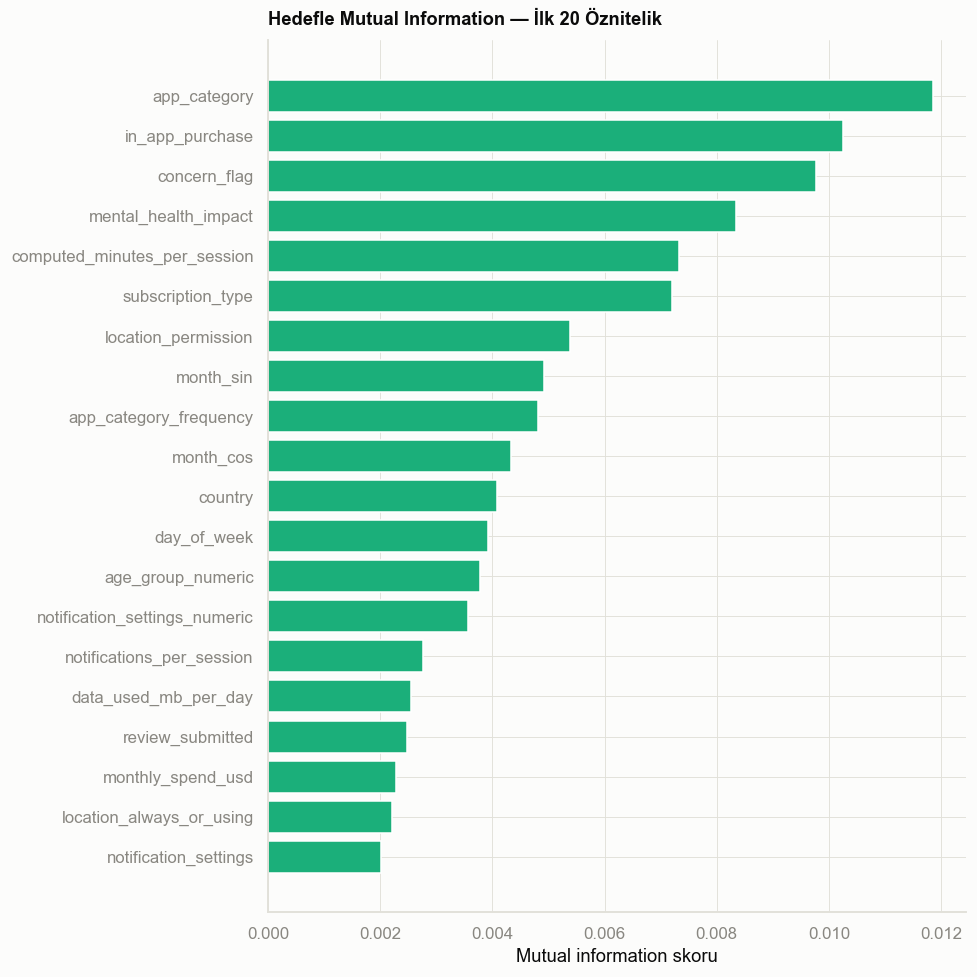

app_category                    0.012
in_app_purchase                 0.010
concern_flag                    0.010
mental_health_impact            0.008
computed_minutes_per_session    0.007
subscription_type               0.007
location_permission             0.005
month_sin                       0.005
app_category_frequency          0.005
month_cos                       0.004
country                         0.004
day_of_week                     0.004
age_group_numeric               0.004
notification_settings_numeric   0.004
notifications_per_session       0.003
data_used_mb_per_day            0.003
review_submitted                0.002
monthly_spend_usd               0.002
location_always_or_using        0.002
notification_settings           0.002
dtype: float64

In [18]:
# Mutual information: kategorik sütunlar label-encode edilerek sayısallarla birleştiriliyor.
# Bu YALNIZCA sıralama/keşif amaçlı -- label encoding, ordinal olmayan kategoriler için
# rastgele bir sayısal sıra empoze eder; bu nedenle mutlak MI değerleri değil, sıralama önemli.
mi_frame = df[all_numeric_for_corr].copy()
for col in categorical_candidates:
    if col == "screen_time_bucket":
        continue
    mi_frame[col] = LabelEncoder().fit_transform(df[col].astype(str))

mi_frame = mi_frame.fillna(mi_frame.median(numeric_only=True))
mi_scores = mutual_info_classif(mi_frame, df["target"], discrete_features="auto", random_state=RANDOM_STATE)
mi_table = pd.Series(mi_scores, index=mi_frame.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
top_mi = mi_table.head(20).iloc[::-1]
ax.barh(top_mi.index, top_mi.values, color=CATEGORICAL[4])
style_ax(ax, title="Hedefle Mutual Information — İlk 20 Öznitelik", xlabel="Mutual information skoru")
plt.tight_layout()
plt.show()

mi_table.head(20)

In [19]:
max_abs_r = numeric_vs_target["point_biserial_r"].abs().max()
max_cramers_v = categorical_vs_target["cramers_v"].max()
n_sig_numeric = (numeric_vs_target["mannwhitney_p"] < 0.05).sum()
n_sig_categorical = (categorical_vs_target["chi2_p"] < 0.05).sum()

print("=" * 78)
print("HEDEFLE İLİŞKİ -- GENEL DEĞERLENDİRME")
print("=" * 78)
print(f"En güçlü sayısal ilişki (|point-biserial r|) : {max_abs_r:.3f}  "
      f"({numeric_vs_target.iloc[0]['oznitelik']})")
print(f"En güçlü kategorik ilişki (Cramér's V)        : {max_cramers_v:.3f}  "
      f"({categorical_vs_target.iloc[0]['oznitelik']})")
print(f"p<0.05 olan sayısal öznitelik sayısı           : {n_sig_numeric} / {len(numeric_vs_target)}")
print(f"p<0.05 olan kategorik öznitelik sayısı          : {n_sig_categorical} / {len(categorical_vs_target)}")
print()
if max_abs_r < 0.1 and max_cramers_v < 0.1:
    print("Yorum: Hem en güçlü sayısal hem de en güçlü kategorik ilişki 'zayıf' eşiğinin")
    print("(|r| veya Cramér's V < 0.1) altında kalıyor -- bu yalnızca yeni türetilen")
    print("özniteliklere değil, HAM sütunlara da (ör. daily_screen_time_minutes,")
    print("sessions_per_day) uygulanıyor. 01_eda.ipynb bölüm 16-17'de 'mental_health_impact'")
    print("için gözlemlenen örüntüyle aynı: ölçülen kullanım davranışı ile bu öznel/davranışsal")
    print("hedef arasında pratik açıdan anlamlı bir ilişki yok. Bu, veri setinin sentetik/simüle")
    print("üretilmiş olabileceğine dair EDA'daki şüpheyi güçlendiriyor -- 'app_deleted_and_reinstalled'")
    print("sütunu da diğer sütunlardan büyük ölçüde bağımsız üretilmiş görünüyor.")
    print()
    print("Pratik sonuç: aşağıdaki eleme adımı, bu zayıf sinyal nedeniyle çoğu türetilmiş")
    print("özniteliği eleyecek. Bu bir hata değil -- verinin kendisinin bir özelliği. Eğer")
    print("ileride bu hedef üzerinde ciddi bir sınıflandırma modeli kurulacaksa, önce bu")
    print("veri setinin gerçekten öngörülebilir bir sinyal taşıyıp taşımadığı sorgulanmalı.")
else:
    print("Yorum: En azından bazı öznitelikler hedefle ölçülebilir düzeyde ilişkili "
          "(|r| veya Cramér's V >= 0.1) -- bu, aşağıdaki elemeden sonra kalan öznitelik "
          "havuzunun modelleme için bir başlangıç noktası oluşturabileceğini gösteriyor.")

HEDEFLE İLİŞKİ -- GENEL DEĞERLENDİRME
En güçlü sayısal ilişki (|point-biserial r|) : 0.037  (age_group_numeric)
En güçlü kategorik ilişki (Cramér's V)        : 0.041  (age_group)
p<0.05 olan sayısal öznitelik sayısı           : 4 / 33
p<0.05 olan kategorik öznitelik sayısı          : 4 / 21

Yorum: Hem en güçlü sayısal hem de en güçlü kategorik ilişki 'zayıf' eşiğinin
(|r| veya Cramér's V < 0.1) altında kalıyor -- bu yalnızca yeni türetilen
özniteliklere değil, HAM sütunlara da (ör. daily_screen_time_minutes,
sessions_per_day) uygulanıyor. 01_eda.ipynb bölüm 16-17'de 'mental_health_impact'
için gözlemlenen örüntüyle aynı: ölçülen kullanım davranışı ile bu öznel/davranışsal
hedef arasında pratik açıdan anlamlı bir ilişki yok. Bu, veri setinin sentetik/simüle
üretilmiş olabileceğine dair EDA'daki şüpheyi güçlendiriyor -- 'app_deleted_and_reinstalled'
sütunu da diğer sütunlardan büyük ölçüde bağımsız üretilmiş görünüyor.

Pratik sonuç: aşağıdaki eleme adımı, bu zayıf sinyal nedeniyle çoğu

## 9. Öznitelik Seçimi — Elemeler

Elemeler iki kural üzerinden **veriden hesaplanarak** (elle seçilmeden) uygulanıyor:

1. **Çoklu doğrusallık:** Bölüm 7'de `|r| >= 0.85` bulunan çiftlerden, hedefle daha zayıf
   ilişkili olan (bölüm 8'deki `mutlak_r` küçük olan) elenir.
2. **Hedefle zayıf ilişki:** Yeni türetilen sayısal öznitelikler için `|point-biserial r| < 0.02`
   olanlar elenir. **Bilinçli olarak yalnızca etki büyüklüğü (effect size) kullanılıyor,
   p-değeri kullanılmıyor** -- n=10.000 gibi büyük bir örneklemde `|r|=0.02` gibi pratikte
   önemsiz bir ilişki bile p<0.05 çıkabilir (bkz. bölüm 8 sonundaki gözlem ve
   `01_eda.ipynb` bölüm 11'deki aynı uyarı). P-değerine göre elemek, tam da bu istatistiksel
   anlamlılık/pratik önem karışıklığına düşerdi.

Ham/kimlik sütunları (`record_id` gibi) ve hedefin kendisini oluşturan
`app_deleted_and_reinstalled` sütunu bu elemeden ayrı tutulur; onlar zaten son sette kalacak.
Orijinal kategorik sütunlar da (veri sözlüğünün bütünlüğü için) korunuyor -- bu bölümdeki
eleme yalnızca bu defterde türetilen **yeni sayısal** özniteliklere uygulanıyor.

In [20]:
# --- Kural 1: çoklu doğrusallık ---
numeric_target_strength = numeric_vs_target.set_index("oznitelik")["point_biserial_r"].abs()
drop_for_collinearity = set()
for _, row in high_corr_pairs.iterrows():
    a, b = row["degisken_1"], row["degisken_2"]
    if a not in numeric_target_strength.index or b not in numeric_target_strength.index:
        continue
    weaker = a if numeric_target_strength[a] < numeric_target_strength[b] else b
    drop_for_collinearity.add(weaker)

print("Çoklu doğrusallık nedeniyle elenen öznitelikler:")
for col in sorted(drop_for_collinearity):
    partner_rows = high_corr_pairs[(high_corr_pairs["degisken_1"] == col) | (high_corr_pairs["degisken_2"] == col)]
    partner = partner_rows.iloc[0]
    other = partner["degisken_2"] if partner["degisken_1"] == col else partner["degisken_1"]
    print(f"  - {col} (r={partner['korelasyon']:.2f} ile {other}; hedefle ilişkisi daha zayıf)")
if not drop_for_collinearity:
    print("  (yok)")

Çoklu doğrusallık nedeniyle elenen öznitelikler:
  - screen_time_concern_numeric (r=0.88 ile concern_flag; hedefle ilişkisi daha zayıf)
  - screen_time_hours (r=1.00 ile daily_screen_time_minutes; hedefle ilişkisi daha zayıf)
  - sleep_disruption_numeric (r=0.89 ile sleep_disruption_flag; hedefle ilişkisi daha zayıf)


In [21]:
# --- Kural 2: hedefle zayıf ilişki (yalnızca yeni türetilen özniteliklerden eleme yapılıyor;
# ham sütunlar veri sözlüğünün bütünlüğü için son sette korunuyor).
# Yalnızca etki büyüklüğü (effect size) kullanılıyor -- p-değeri KASITLI OLARAK dahil edilmiyor
# (bkz. yukarıdaki yorum: büyük n'de p-değeri pratik önemsizliği maskeleyebilir). ---
WEAK_R_THRESHOLD = 0.02

weak_numeric = numeric_vs_target[
    (numeric_vs_target["oznitelik"].isin(new_numeric_features))
    & (numeric_vs_target["point_biserial_r"].abs() < WEAK_R_THRESHOLD)
]["oznitelik"].tolist()

print("Hedefle zayıf ilişkili olduğu için (etki büyüklüğü |r| < 0.02) elenen yeni sayısal öznitelikler:")
print(f"  {weak_numeric if weak_numeric else '(yok)'}")

drop_features = set(weak_numeric) | drop_for_collinearity
kept_features = [c for c in new_numeric_features if c not in drop_features]

print(f"\nToplam aday: {len(new_numeric_features)}  ->  Elenen: {len(drop_features)}  ->  Kalan: {len(kept_features)}")
print(f"\nKalan öznitelikler: {kept_features}")

Hedefle zayıf ilişkili olduğu için (etki büyüklüğü |r| < 0.02) elenen yeni sayısal öznitelikler:
  ['daily_battery_load', 'notifications_per_session', 'computed_minutes_per_session', 'high_screen_time_flag', 'concern_flag', 'is_payer', 'screen_time_hours', 'is_ios', 'sleep_disruption_flag', 'dark_mode_numeric', 'is_weekend', 'screen_time_concern_numeric', 'spend_per_minute', 'opens_per_session', 'app_category_frequency', 'wellbeing_risk_score', 'month_cos', 'is_paid_subscription', 'sleep_disruption_numeric', 'notification_settings_numeric', 'data_mb_per_minute']

Toplam aday: 24  ->  Elenen: 21  ->  Kalan: 3

Kalan öznitelikler: ['age_group_numeric', 'month_sin', 'location_always_or_using']


## 10. Son Veri Setinin Oluşturulması ve Kaydedilmesi

Son veri seti = **tüm orijinal ham sütunlar** (değiştirilmeden) + **elemeyi geçen yeni
öznitelikler** + hedef değişkenin ikili kodu (`target`). Ham CSV dosyasına hiçbir yazma
işlemi yapılmıyor; çıktı yalnızca `data/processed/` altına, farklı bir dosya adıyla kaydediliyor.

In [22]:
original_raw_cols = [
    "record_id", "year", "month", "quarter", "day_of_week", "country", "age_group", "gender",
    "device_brand", "operating_system", "network_connection", "app_category", "app_name",
    "subscription_type", "daily_screen_time_minutes", "session_duration_minutes",
    "sessions_per_day", "app_opens_per_day", "data_used_mb_per_day", "battery_drain_pct_per_session",
    "notifications_received_per_day", "notification_settings", "in_app_purchase",
    "monthly_spend_usd", "app_rating_given", "review_submitted", "primary_usage_time",
    "dark_mode_preference", "location_permission", "sleep_disruption_from_phone",
    "screen_time_concern", "mental_health_impact", "digital_wellbeing_feature_used",
    "app_deleted_and_reinstalled",
]

final_cols = original_raw_cols + kept_features + ["target"]
final_df = df[final_cols].copy()

print(f"Son veri seti boyutu: {final_df.shape[0]:,} satır x {final_df.shape[1]} sütun")
print(f"  - Orijinal ham sütun sayısı : {len(original_raw_cols)}")
print(f"  - Elemeyi geçen yeni öznitelik sayısı : {len(kept_features)}")
print(f"  - Hedef değişken (target) eklendi")
final_df.head(3)

Son veri seti boyutu: 10,000 satır x 38 sütun
  - Orijinal ham sütun sayısı : 34
  - Elemeyi geçen yeni öznitelik sayısı : 3
  - Hedef değişken (target) eklendi


,record_id,year,month,quarter,day_of_week,country,age_group,gender,device_brand,operating_system,network_connection,app_category,app_name,subscription_type,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,data_used_mb_per_day,battery_drain_pct_per_session,notifications_received_per_day,notification_settings,in_app_purchase,monthly_spend_usd,app_rating_given,review_submitted,primary_usage_time,dark_mode_preference,location_permission,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used,app_deleted_and_reinstalled,age_group_numeric,month_sin,location_always_or_using,target
0,APP0000001,2024,11,Q4,Thursday,Turkey,45-54,Male,Xiaomi,Android,WiFi,Social Media,Snapchat,Paid Yearly,76.400,41.000,9,12,159.200,3.000,26,Selected Only,Yes,65.280,4,No,Lunch (12-2pm),Sometimes,While Using,Moderate,Yes,Positive,Yes,Yes,49.500,-0.500,1,1
1,APP0000002,2022,5,Q2,Friday,USA,25-34,Male,Huawei,Android,WiFi,Shopping,Etsy,Freemium,82.200,19.300,6,9,46.700,11.800,25,Selected Only,No,0.000,4,Yes,Evening (6-10pm),Sometimes,Never,NaN,Yes,Negative,Yes,Yes,29.500,0.500,0,1
2,APP0000003,2024,9,Q3,Sunday,USA,25-34,Male,Samsung,Android,4G/LTE,Food Delivery,Deliveroo,Free,15.800,18.000,2,5,128.900,10.300,25,Selected Only,No,0.000,4,Yes,Evening (6-10pm),Sometimes,While Using,NaN,No,Negative,No,Yes,29.500,-1.000,1,1


In [23]:
# Ham veri gerçekten değişmedi mi? -- dosyanın SHA-256 özeti, bu defter başında okunduğu
# andaki değeriyle karşılaştırılıyor. Eşitse, ham CSV'ye hiçbir bayt yazılmamış demektir.
raw_file_hash_now = hashlib.sha256(RAW_DATA_PATH.read_bytes()).hexdigest()
assert raw_file_hash_now == RAW_FILE_HASH_AT_LOAD, "Ham veri dosyası beklenmedik şekilde değişti!"
print(f"Ham CSV dosyası bu defter çalışırken değişmedi (SHA-256 doğrulandı): {raw_file_hash_now == RAW_FILE_HASH_AT_LOAD}")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = PROCESSED_DIR / "mobile_app_usage_features.csv"
final_df.to_csv(OUTPUT_PATH, index=False)

print(f"\nSon veri seti kaydedildi: {OUTPUT_PATH}")
print(f"Dosya boyutu: {OUTPUT_PATH.stat().st_size / 1e6:.2f} MB")

Ham CSV dosyası bu defter çalışırken değişmedi (SHA-256 doğrulandı): True

Son veri seti kaydedildi: /Users/omerburaksal/Desktop/projects/data_science/product_level_mobile/data/processed/mobile_app_usage_features.csv
Dosya boyutu: 2.44 MB


## 11. Özet

- Hedef değişken olarak `01_eda.ipynb`'in önerdiği `app_deleted_and_reinstalled` seçildi
  (ikili kod: `target`).
- Beş grupta (kullanım oranları, parasal, ordinal kodlama, zamansal, kategorik bayrak/sıklık
  ve bileşik dijital refah göstergeleri) bölüm 5'te listelenen aday öznitelikler türetildi
  (tam sayı ve elemeden sonra kalanlar için bkz. bölüm 9 çıktısı).
- Dağılımlar, çoklu doğrusallık ve hedefle ilişki (point-biserial, Cramér's V, mutual information)
  incelendi; zayıf/gereksiz olanlar veriden hesaplanan eşiklerle elendi.
- Hedefle **doğrudan sızıntı (leakage)** riski taşıyan bir kodlama (ör. kategori bazında hedef
  ortalaması) bilinçli olarak eklenmedi; bu tür kodlamalar ancak çapraz doğrulama içinde
  güvenle üretilebilir.
- Son veri seti, ham veriye dokunulmadan `data/processed/mobile_app_usage_features.csv` olarak
  kaydedildi.

### Sonraki Adım

`03_modeling.ipynb`: bu işlenmiş veri seti üzerinde train/test ayrımı, kategorik kodlama
(one-hot / target encoding çapraz doğrulama içinde), temel bir sınıflandırma modeli
(ör. lojistik regresyon + gradient boosting karşılaştırması) ve değerlendirme metrikleri.